<a href="https://colab.research.google.com/github/aizarasool0-wq/AI-ML-DL/blob/main/Assighnment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
from google.colab import files
uploaded = files.upload()

Saving 50_startups_dataset.csv to 50_startups_dataset.csv


In [7]:
df = pd.read_csv('50_startups_dataset.csv')

In [8]:
df.info()
df.describe()
print("Shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB
Shape: (50, 5)


In [9]:
df.info()
df.describe()
print("Shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB
Shape: (50, 5)


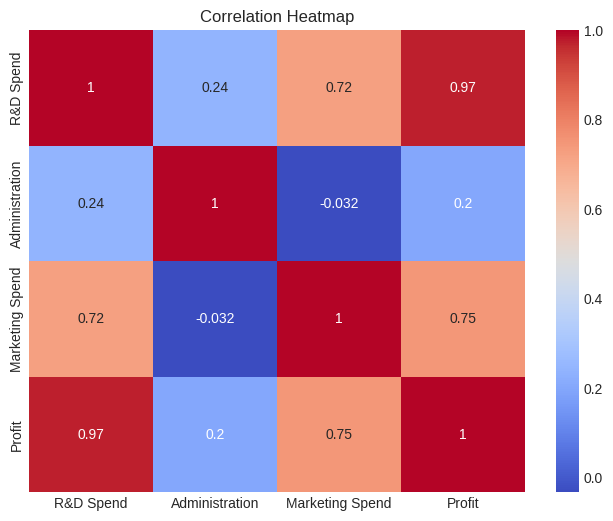

In [10]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

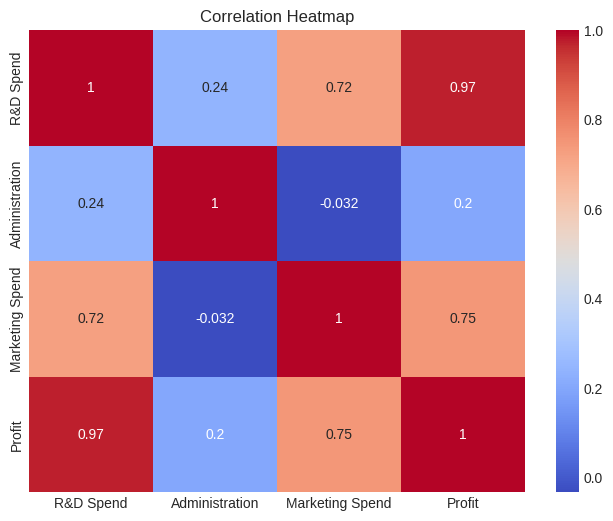

In [11]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

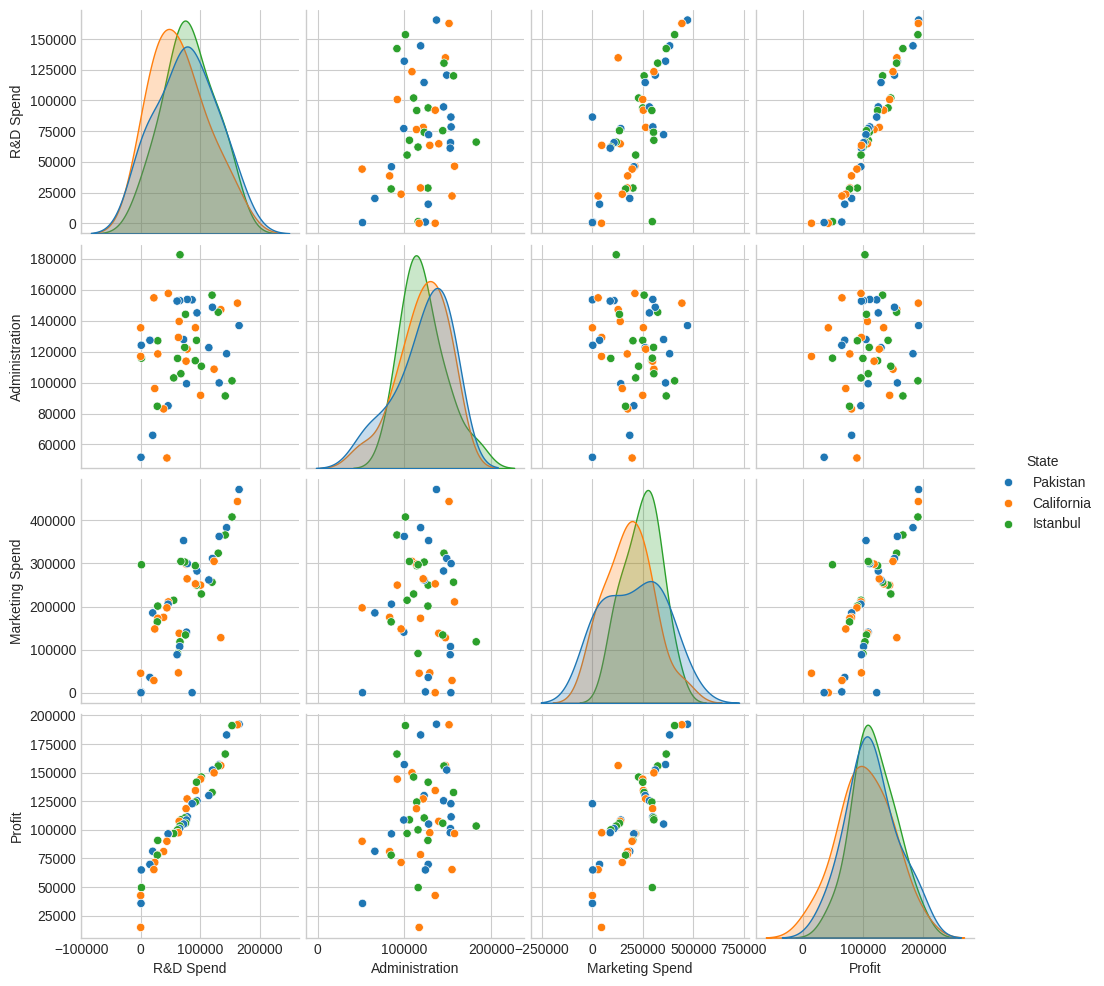

In [12]:
# Pairplot
sns.pairplot(df, hue='State')
plt.show()


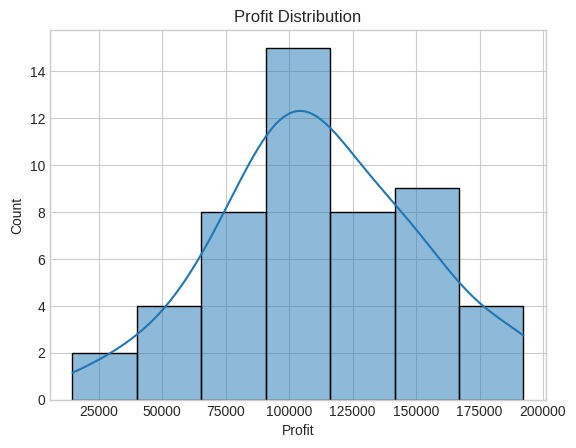

In [13]:
# Profit Distribution
sns.histplot(df['Profit'], kde=True)
plt.title("Profit Distribution")
plt.show()

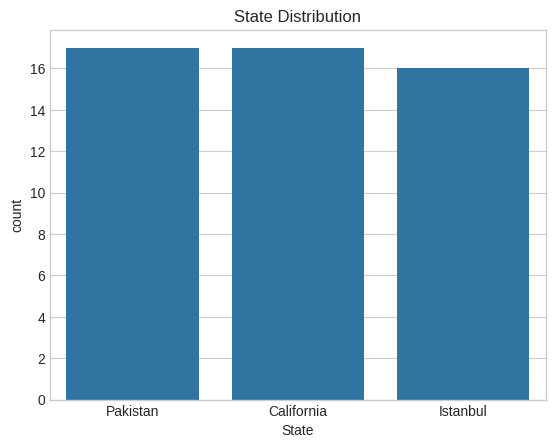

In [14]:
# State Distribution
sns.countplot(x='State', data=df)
plt.title("State Distribution")
plt.show()

In [15]:
# One-hot encoding
df_encoded = pd.get_dummies(df, columns=['State'], drop_first=True)

# Features & target
X = df_encoded.drop('Profit', axis=1)
y = df_encoded['Profit']

print(X.head())

   R&D Spend  Administration  Marketing Spend  State_Istanbul  State_Pakistan
0  165349.20       136897.80        471784.10           False            True
1  162597.70       151377.59        443898.53           False           False
2  153441.51       101145.55        407934.54            True           False
3  144372.41       118671.85        383199.62           False            True
4  142107.34        91391.77        366168.42            True           False


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (40, 5)
Test: (10, 5)


In [19]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)

print("\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(feature, ":", coef)

Intercept: 54028.03959364581

Coefficients:
R&D Spend : 0.8056300637153672
Administration : -0.06878788227713217
Marketing Spend : 0.029855442922634076
State_Istanbul : 938.7930061484369
State_Pakistan : 6.987759966982041


In [20]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Difference": y_test.values - y_pred
})

comparison.head()

,Actual,Predicted,Difference
0,134307.35,126362.879083,7944.470917
1,81005.76,84608.453836,-3602.693836
2,99937.59,99677.494251,260.095749
3,64926.08,46357.460686,18568.619314
4,125370.37,128750.482885,-3380.112885


In [21]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Difference": y_test.values - y_pred
})

comparison.head()

,Actual,Predicted,Difference
0,134307.35,126362.879083,7944.470917
1,81005.76,84608.453836,-3602.693836
2,99937.59,99677.494251,260.095749
3,64926.08,46357.460686,18568.619314
4,125370.37,128750.482885,-3380.112885


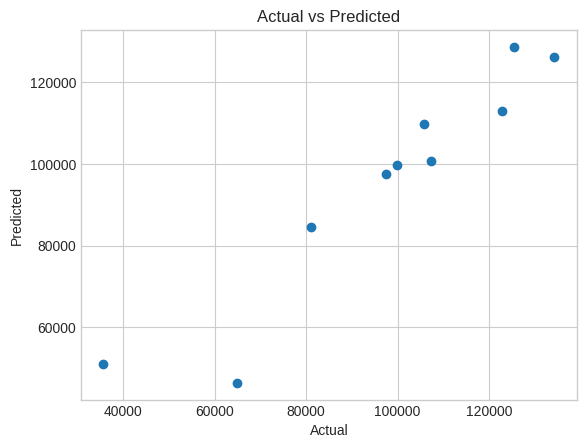

In [22]:
# Actual vs Predicted
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

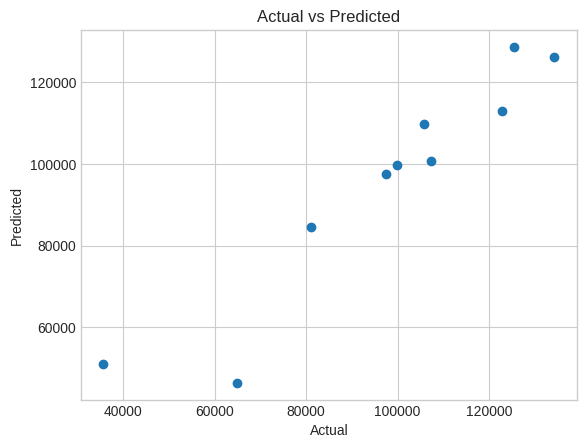

In [23]:
# Actual vs Predicted
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

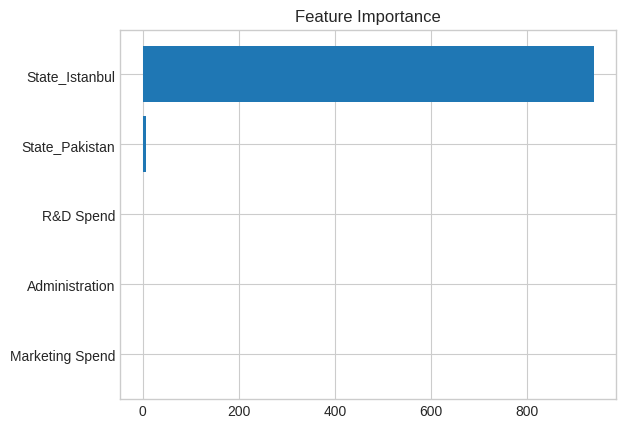

,Feature,Coefficient
2,Marketing Spend,0.029855
1,Administration,-0.068788
0,R&D Spend,0.805630
4,State_Pakistan,6.987760
3,State_Istanbul,938.793006


In [24]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", key=abs)

plt.barh(importance["Feature"], importance["Coefficient"])
plt.title("Feature Importance")
plt.show()

importance

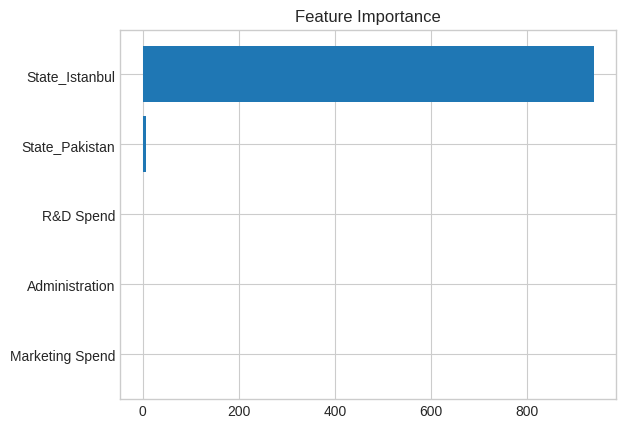

,Feature,Coefficient
2,Marketing Spend,0.029855
1,Administration,-0.068788
0,R&D Spend,0.805630
4,State_Pakistan,6.987760
3,State_Istanbul,938.793006


In [25]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", key=abs)

plt.barh(importance["Feature"], importance["Coefficient"])
plt.title("Feature Importance")
plt.show()

importance